## Error por truncamiento - Aproximación del seno por la serie alternada de Taylor
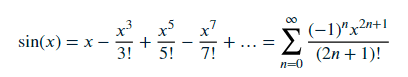

### Versión 1 - Iterativa con factorial

In [ ]:
function seno_aprox_v1(a, tol)

  x = (a / (180 / pi))
  res = 0
  i = 0

  continuar = true

  while (continuar == true)
    sign = (-1) ^ i
    exp = 2 * i + 1
    num = x ^ exp

    #=
    Realizar una primera ejecución con factorial (exp)
    OverflowError: 21 is too large to look up in the table; consider using 'factorial(big(21))' instead
    =#

    den = factorial(big(exp))
    term = num / den

    res = res + sign * term
    if (term < tol)
      continuar = false
    else
      i = i + 1
    end
  end
  return(res)
end

angulos = [30, 390, 750, 1110, 1470, 1830, 2190, 2550, 2910]
for ang in angulos
  println("Angulo: $(ang) Aprox por Julia: $(sind(ang)) Aprox por Taylor: $(seno_aprox_v1(ang, 10 ^ -8))")
end

Angulo: 30 Aprox por Julia: 0.5 Aprox por Taylor: 0.5000000000202798708234233195763128432441402447506016682064722454737103174603143
Angulo: 390 Aprox por Julia: 0.5 Aprox por Taylor: 0.499999999659791619491787674219645887027543053670372339195034190515988455792279
Angulo: 750 Aprox por Julia: 0.5 Aprox por Taylor: 0.500000000560528550982522328900382407575318178699681959814278685876206471691169
Angulo: 1110 Aprox por Julia: 0.5 Aprox por Taylor: 0.5000000006650019153327942965671876468710070568580848328517132052183053234093618
Angulo: 1470 Aprox por Julia: 0.5 Aprox por Taylor: 0.4999992108671927133679020627244947798241598154458102344708373536262832209173069
Angulo: 1830 Aprox por Julia: 0.5 Aprox por Taylor: 0.4997280915166671730447961790188914573446291443936146678528585494306775925616189
Angulo: 2190 Aprox por Julia: 0.5 Aprox por Taylor: 0.05839142909476718994465297697409956596785744609232692440491755036516550259259946
Angulo: 2550 Aprox por Julia: 0.5 Aprox por Taylor: -198.0167376127

### Versión 2 - Iterativa con recurrencia

In [ ]:
function seno_aprox_v2(a, tol)

  x = a / (180 / pi)
  res = x
  term = x
  denom = 3.0
  x_cuad = x ^ 2
  continuar = true

  while (continuar == true)
    # -(x*x²)/3*(2)
    term = (-(term * x_cuad)) / ((denom) * (denom - 1))
    res = res + term

    if (abs(term) < tol)
       continuar = false
    else
       denom = denom + 2
    end
  end

  return (res)
end

angulos = [30, 390, 750, 1110, 1470, 1830, 2190, 2550, 2910]
for ang in angulos
  println("Angulo: $(ang) Aprox por Julia: $(sin(ang)) Aprox por Taylor: $(seno_aprox_v2(ang, 10 ^ -8))")
end

Angulo: 30 Aprox por Julia: 0.5 Aprox por Taylor: 0.5000000000202799
Angulo: 390 Aprox por Julia: 0.5 Aprox por Taylor: 0.4999999996598002
Angulo: 750 Aprox por Julia: 0.5 Aprox por Taylor: 0.5000000005590153
Angulo: 1110 Aprox por Julia: 0.5 Aprox por Taylor: 0.5000000013676369
Angulo: 1470 Aprox por Julia: 0.5 Aprox por Taylor: 0.499998625213045
Angulo: 1830 Aprox por Julia: 0.5 Aprox por Taylor: 0.4994600400073118
Angulo: 2190 Aprox por Julia: 0.5 Aprox por Taylor: 0.3778680334712677
Angulo: 2550 Aprox por Julia: 0.5 Aprox por Taylor: -63.77897679167657
Angulo: 2910 Aprox por Julia: 0.5 Aprox por Taylor: -86268.91319879345
